<a href="https://colab.research.google.com/github/naaash03/AncestryTreeProject/blob/main/Capstone_Project/Milestone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Milestone 1 — Project Proposal, Dataset Discovery & Problem Definition

####Adam Nash
####3/23/26


##Problem Statement:

####For this project I want to build a binary image classification that will determine wheteher a baseball pitch is a ball or a called strike from a single broadcast video frame.

####In the MLB, the accuracy of the ball and strike calls by human umpires has been a persistent source of controversey throughout the history of the league despite adding a fundamental 'human' aspect to the game. Studies from MLB's own Statcast system suggest that an umpo=ire will miss on average around 10-15% of calls per game with that number growing in more intense in-game situations. Automating this process is something that can provide a valuable accessible alternative for real-time analysis.

####This project will formulate the umpire decision as a supervised binary classification problem. Given a 224x 224 RGB image, which in the case of the dataset will be a representative frame extracted from a broadcast video clip of a pitch, the system must predict:

###Class 0 - Ball: The pitch was outside the strike zone

###&

###Class 1 - Strike: The pitch was inside the strike zone

####This approach will allow me to then train a convolutional neural network from scratch and compare it against a fine-tuned pretrained model.

##Expected input:
####The expected input to the system will either be short video clips of single pitches from the MLB or a small set of sampled frames in a RBG format that are extracted from that clip. With the dataset I chose each clip is already preprocessed into .mp4 format and resides to a resolution of 224 x 224, making the data practical for our uses.

##Expected output:
####I expect the output to be a binary class label that predicts whether the pitch in question should be judged as a ball or a called strike. In laymans terms the model will decide wheter the pitch passed through the legal target area that the batter is expected to defend. aka the strike zone. for the implementation I will assign 0 for ball and 1 for called strike.


##Dataset Description
###Source and accessibility:
####I plan to use the picklebot-130k dataset which is publically availble on Hugging Face. It is listed under video classification dataset and its been released under a liscense from MIT. It also includes the metadata files and links to the full video archive.

###Characteristics:
####The dataset is populated with roughly 130,000 short video clips of individual MLB pitches. It includes three official splits: training, validation, and test which is even better for our purposes. Again, they are stored in 224 x 224 videos and the metadata includes columns like pitch type, velocity, spin rate, pitcher, batter, zone, count, inning, pitch result, video link, filename, and videolength. I will mostly be looking to work towards classifing the labels for ball and called strike.

###Why this dataset is suitable:
####I feel this dataset is a strong match for the project I want to work on. It directly supports the problem I want to solve: learning from visual pitch clips to predict a two-class decision. Since I dont need to build labels from scratch, the data will provide all that I need for the binary outcomes. It is also large enough for deep learning to take place.

###Evidence this dataset is not a standard dataset
####This dataset was not from Kaggle nor is it a competitor dataset. It is also not a standard dataset. It is niche and designed for a specialized classification problem.

###Preprocessing
####The dataset already includes labels so I dont expect a major amount of manual preprocessing for that. My main preprocessing steps I expect to spend time on is likely loading the video files, taking a sample of the frames from each clip, converting the text lablels into binary numeric labels, normalize pixel values, and then check for issues like class imbalance or unreadable clips. I might also use the metadata to filter and or organize the data for training.

##Link to dataset
####https://huggingface.co/datasets/hbfreed/Picklebot-130K


In [2]:
#Install the packages needed for loading the dataset metadata, handling video files and displaying a sample frame

#Im using pandas for the metadata tables
#matplotlib for displaying the sample frames
#imageio to help read the .mp4 video files
#requests and tarfile will help me access the sample clips from the dataset

!pip -q install pandas matplotlib imageio imageio-ffmpeg requests

In [31]:
#Import libraries I will use

import os
import tarfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v3 as iio
import cv2

In [14]:
#In this cell I define the main dataset links in variables
dataset_page ="https://huggingface.co/datasets/hbfreed/Picklebot-130K"

train_csv_url = "https://huggingface.co/datasets/hbfreed/Picklebot-130K/resolve/main/picklebot_130k_train.csv"
val_csv_url = "https://huggingface.co/datasets/hbfreed/Picklebot-130K/resolve/main/picklebot_130k_val.csv"
test_csv_url = "https://huggingface.co/datasets/hbfreed/Picklebot-130K/resolve/main/picklebot_130k_test.csv"

archive_url = "https://huggingface.co/datasets/hbfreed/Picklebot-130K/resolve/main/picklebot_130k.tar.xz"

print("Dataset page:")
print(dataset_page)

Dataset page:
https://huggingface.co/datasets/hbfreed/Picklebot-130K


In [15]:
#in this cell i create folders where I will save the metadata files  and a couple sample clips

os.makedirs("picklebot_data", exist_ok=True)
os.makedirs("picklebot_data/sample_clips",exist_ok=True)

In [17]:
#In this cell I download the train, validation, and test CSV files that contain labels and metadata for the pitch clips

!wget -q -O picklebot_data/picklebot_130k_train.csv $train_csv_url
!wget -q -O picklebot_data/picklebot_130k_val.csv $val_csv_url
!wget -q -O picklebot_data/picklebot_130k_test.csv $test_csv_url

print("Metadata files downloaded")

Metadata files downloaded


In [13]:
#In this cell I load the CSV files into pandas DataFrames and add a split column so I can clearly see what rows beling to train, validation, and test

train_df = pd.read_csv("picklebot_data/picklebot_130k_train.csv")
val_df = pd.read_csv("picklebot_data/picklebot_130k_val.csv")
test_df = pd.read_csv("picklebot_data/picklebot_130k_val.csv")

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

#Now I combine the tables into one complete table
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Shape train_df:", train_df.shape)
print("Shape val_df:", val_df.shape)
print("Shape test_df:", test_df.shape)
print("Shape all_df:", all_df.shape)

Shape train_df: (103724, 14)
Shape val_df: (12965, 14)
Shape test_df: (12965, 14)
Shape all_df: (129654, 14)


In [18]:
#Here i show the first couple rows of the metadata
display(all_df.head())
print("Available columns:")
print(all_df.columns.tolist())

,date,pitch,mph,spin_rate,pitcher,batter,zone,count,inning,pitch_result,video_link,filename,video_length,split
0,2018-06-15,FF,94.8,2256.0,"Gausman, Kevin(R)","Shuck, JB(L)",6,2-2,Top 2,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_21926.mp4,200,train
1,2017-06-06,FF,91.3,2443.0,"GarcÃ­a, Jaime(L)","Herrera, OdÃºbel(L)",6,0-0,Top 1,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_68278.mp4,200,train
2,2018-04-14,FF,89.8,2010.0,"Quintana, JosÃ©(L)","Bourjos, Peter(R)",4,0-0,Top 3,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_54570.mp4,200,train
3,2018-09-02,SI,93.7,2353.0,"Ottavino, Adam(R)","Myers, Wil(R)",4,0-2,Bot 8,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_73803.mp4,200,train
4,2017-07-18,KC,87.1,2560.0,"Kimbrel, Craig(R)","Bautista, JosÃ©(R)",0,0-0,Top 9,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_29669.mp4,200,train


Available columns:
['date', 'pitch', 'mph', 'spin_rate', 'pitcher', 'batter', 'zone', 'count', 'inning', 'pitch_result', 'video_link', 'filename', 'video_length', 'split']


In [19]:
#Here I print the dataset stats like number of samples and class distribution
print("Total number of clips:", len(all_df))
print()

print("Split counts:")
print(all_df["split"].value_counts())
print()

print("Class distribution:")
print(all_df["pitch_result"].value_counts(dropna=False))
print()

print("Class distribution by split:")
print(pd.crosstab(all_df["split"], all_df["pitch_result"]))

Total number of clips: 129654

Split counts:
split
train         103724
validation     12965
test           12965
Name: count, dtype: int64

Class distribution:
pitch_result
Called Strike    81570
Ball             48084
Name: count, dtype: int64

Class distribution by split:
pitch_result   Ball  Called Strike
split                             
test           4725           8240
train         38634          65090
validation     4725           8240


In [22]:
#For this milestone I only will show a few example clips
#In this cell I stream the archive and save the first 6 .mp4 files I find.

sample_folder = "picklebot_data/sample_clips"

#Before I do anything I remove sample clips so I dont mix files from different runs
for file_name in os.listdir(sample_folder):
  if file_name.endswith(".mp4"):
    os.remove(os.path.join(sample_folder, file_name))

response = requests.get(archive_url, stream=True)
response.raise_for_status()

saved_count = 0

with tarfile.open(fileobj = response.raw, mode = "r|xz") as tar:
  for member in tar:
    if member.isfile() and member.name.endswith(".mp4"):
      clip_name = os.path.basename(member.name)
      out_path = os.path.join(sample_folder, clip_name)

      extracted_file = tar.extractfile(member)

      if extracted_file is not None:
        with open(out_path, "wb") as out_file:
          out_file.write(extracted_file.read())

        saved_count = saved_count + 1
        print("Saved:", clip_name)

      if saved_count == 6:
        break

print()
print("Total sample clips saved:", saved_count)

Saved: clip_72744.mp4
Saved: clip_55337.mp4
Saved: clip_76508.mp4
Saved: clip_101785.mp4
Saved: clip_17952.mp4
Saved: clip_93657.mp4

Total sample clips saved: 6


In [28]:
# In this cell I pick a few sample clips only from the training split.

sample_names = train_df["filename"].head(6).tolist()

print("Sample filenames:")
for name in sample_names:
  print(name)

Sample filenames:
clip_21926.mp4
clip_68278.mp4
clip_54570.mp4
clip_73803.mp4
clip_29669.mp4
clip_65922.mp4


In [35]:
#In this cell I define a smaller helper function that will read a video and return the middle frame
#I will use the middle frame as a sample image representation of the clip

def get_middle_frame(video_path):
  cap = cv2.VideoCapture(video_path)

  #If file cant be opened return None
  if not cap.isOpened():
    return None

  #here i get the total number of frames in the clip
  frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

  #if openCV read the frame count close and return None
  if frame_count == 0:
    cap.release()
    return None

  #Compute the middle frame index
  middle_index = frame_count // 2

  #Now jump directly to the middle frame
  cap.set(cv2.CAP_PROP_POS_FRAMES, middle_index)

  #and read the one frame
  success, frame = cap.read()

  #Release the video object when fished
  cap.release()

  #If read fails reaturn none
  if not success:
    return None

  #openCV will read the img in BGR order so ill convert to RGB
  frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

  return frame

In [36]:
# In this cell I check which sample clips are actually inside the folder.
# This helps me make sure I only try to display files that really exist.

sample_folder = "picklebot_data/sample_clips"

sample_names = sorted([name for name in os.listdir(sample_folder) if name.endswith(".mp4")])

print("Number of sample clips found:", len(sample_names))
print()

for name in sample_names:
    print(name)

Number of sample clips found: 6

clip_101785.mp4
clip_17952.mp4
clip_55337.mp4
clip_72744.mp4
clip_76508.mp4
clip_93657.mp4


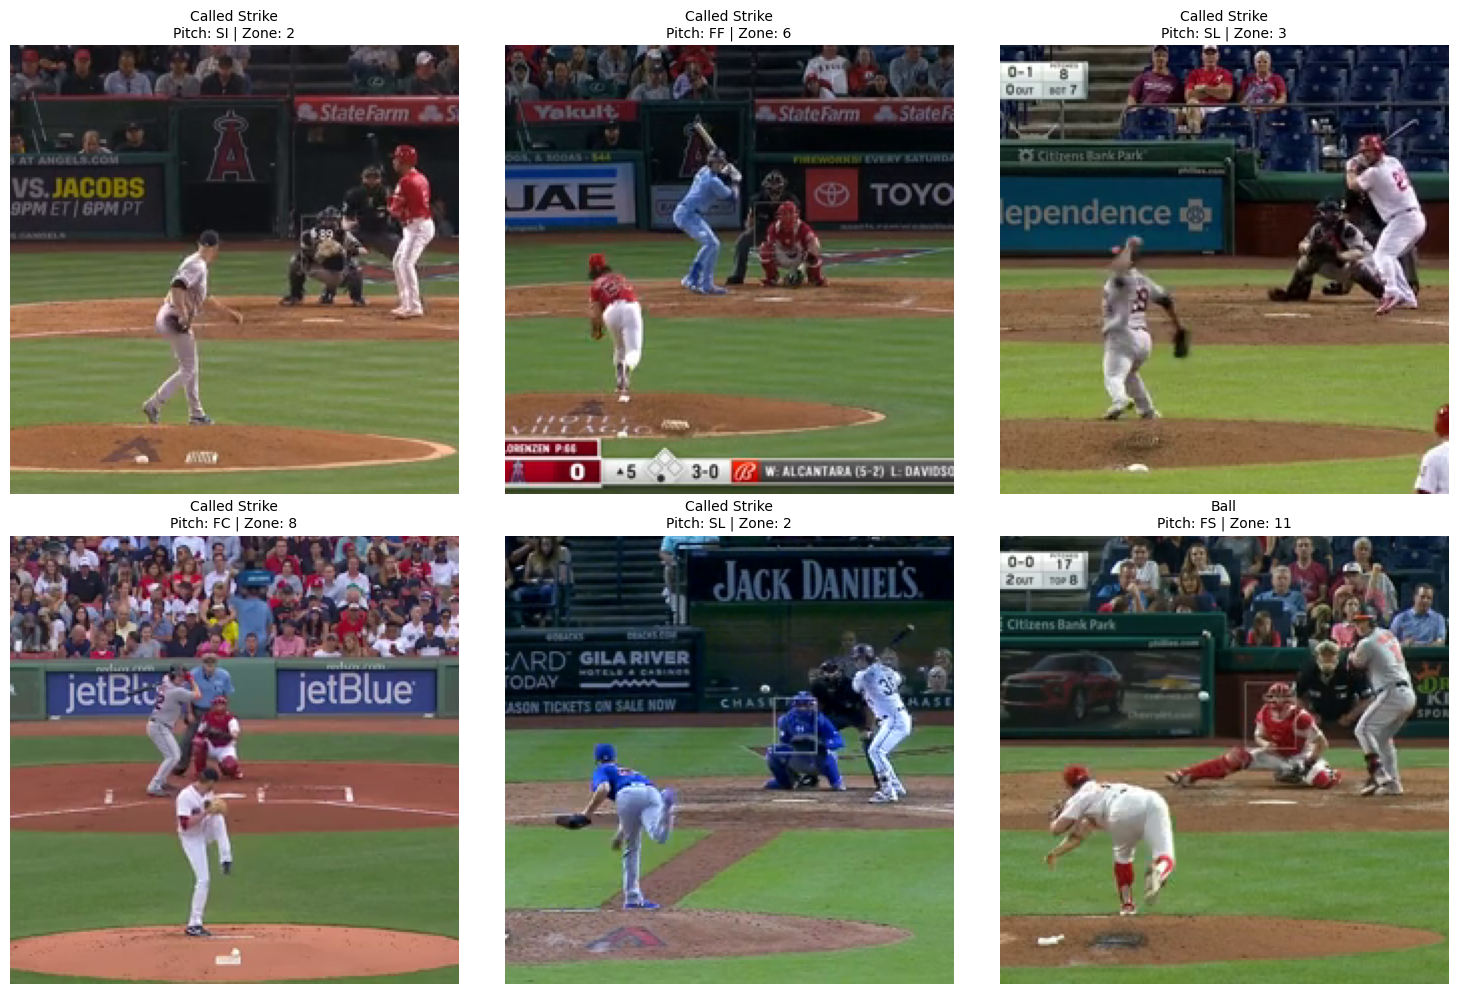

In [37]:
#In this cell I display the sample images with their lables
#Each image will be the middle frame of one pitch clip

fig, axes = plt.subplots(2, 3, figsize = (15, 10))
axes = axes.ravel()

#only use 6 clips
sample_names = sample_names[:6]

for i in range(len(sample_names)):
  clip_name = sample_names[i]
  clip_path = os.path.join(sample_folder, clip_name)

  frame = get_middle_frame(clip_path)

  #if the frame cant be read skip the clip
  if frame is None:
    axes[i].set_title("Could not be read: " + clip_name)
    axes[i].axis("off")
    continue

  # Find the metadata row that matches this filename.
  row_matches = all_df[all_df["filename"] == clip_name]

  #if there is more then one row match we use the first one
  row = row_matches.iloc[0]

  label_text = row["pitch_result"]
  split_text = row["split"]
  pitch_text = row["pitch"]
  zone_text = row["zone"]

  axes[i].imshow(frame)
  axes[i].set_title(label_text + "\nPitch: " + str(pitch_text) + " | Zone: " + str(zone_text), fontsize=10)
  axes[i].axis("off")

# If fewer than 6 clips exist, turn off the extra empty axes.
for j in range(len(sample_names), 6):
    axes[j].axis("off")

plt.tight_layout()
plt.show()